# Setup (Imports and Preparations)

In [1]:
import cProfile
import pstats
import io
import time
import matplotlib.pyplot as plt
import numpy as np

import ActivationPrototypes_SARSeg.thesis_utils as utils
from ActivationPrototypes_SARSeg.thesis_utils import *

2025-05-26 13:10:14.629 | INFO     | ActivationPrototypes_SARSeg.config:<module>:11 - PROJ_ROOT path is: F:\Thesis\ActivationPrototypes_SARSeg
f:\Thesis\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_lmdb_path = '../data/BigEarthNet/Encoded-BigEarthNet'
parquet_path = '../data/BigEarthNet/metadata.parquet'
prototype_lmdb_path = "../data/BigEarthNet/prototypes_subsample"

device = 'cuda' if torch.cuda.is_available() else 'cpu'
layer_names = ["encoder.layer3", "encoder.layer4", "decoder.up1", "decoder.up2"]

IMG_SIZE = (120,120)
IMG_HEIGHT = 120
IMG_WIDTH  = 120
IMG_CHANNELS = 2

model = load_from_checkpoint_skipconn("../models/unet120_full_skipconn_best.pth")
model.eval()
model.to(device);

CustomUnet initialized with encoder channels: (2, 64, 256, 512, 1024, 2048)


In [3]:
train_matches, val_matches, test_matches = match_keys(parquet_path)

random.seed(42)
train_matches_subsample = random.sample(train_matches, len(train_matches)//10)

subsample_image_keys = []
subsample_mask_keys = []
# for match in old_train_matches:
for match in train_matches_subsample:
    train_image_key, train_mask_key = match
    subsample_image_keys.append(train_image_key)
    subsample_mask_keys.append(train_mask_key)

print(train_matches_subsample[:5])

[('S1A_IW_GRDH_1SDV_20180126T161302_34VDN_15_88', 'S2B_MSIL2A_20180127T102259_N9999_R065_T34VDN_15_88_reference_map'), ('S1A_IW_GRDH_1SDV_20170903T153258_35VNL_70_4', 'S2A_MSIL2A_20170905T095031_N9999_R079_T35VNL_70_04_reference_map'), ('S1A_IW_GRDH_1SDV_20170617T064659_29UPU_62_3', 'S2A_MSIL2A_20170617T113321_N9999_R080_T29UPU_62_03_reference_map'), ('S1A_IW_GRDH_1SDV_20180420T063917_29UPU_27_80', 'S2B_MSIL2A_20180421T114349_N9999_R123_T29UPU_27_80_reference_map'), ('S1A_IW_GRDH_1SDV_20180413T161957_34UEG_40_3', 'S2A_MSIL2A_20180413T095031_N9999_R079_T34UEG_40_03_reference_map')]


In [19]:
query_image_reference = 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_55_62'
test_img, _ = get_image_and_mask_from_key(query_image_reference, lmdb_path=dataset_lmdb_path)

runtime_data = {}

layer_subsets = {
    "1 Layer": layer_names[:1],
    "2 Layers": layer_names[:2],
    "3 Layers": layer_names[:3],
    "4 Layers": layer_names[:4]
}

grid_splits = {
    "2x2 Grid": (IMG_WIDTH / 2, IMG_HEIGHT / 2),
    "4x4 Grid": (IMG_WIDTH / 4, IMG_HEIGHT / 4),
    "8x8 Grid": (IMG_WIDTH / 8, IMG_HEIGHT / 8), 
}

num_trials = 3

print("Starting profiling")

for grid_name, (region_w, region_h) in grid_splits.items():
    print(f"\n Testing {grid_name} ---")
    runtime_data[grid_name] = {}

    for layer_set_name, current_layers in layer_subsets.items():
        print(f"  Testing {layer_set_name}...")
        
        grid_cells_factor = (IMG_WIDTH // int(region_w)) * (IMG_HEIGHT // int(region_h))

        single_region_times_for_avg = []
        
        for idx in range(num_trials):
            print(f"    Run {idx + 1}/{num_trials}...")
            profiler = cProfile.Profile()
            profiler.enable()

            find_n_similar_images(
                test_img,
                current_layers,
                subsample_image_keys,
                prototype_lmdb_path,
                dataset_lmdb_path,
                model,
                img_hw=IMG_SIZE,
                region_coords=(0, 0, region_w, region_h),
                plotting=False, 
            )

            profiler.disable()
            s = io.StringIO()
            sortby = pstats.SortKey.TIME
            ps = pstats.Stats(profiler, stream=s).sort_stats(sortby)

            # Print top 10 lines
            print(f"    Raw Profile Output (top 10 lines for {layer_set_name}, {grid_name}):")
            ps.print_stats(10)
            print(s.getvalue())
            print("------------------\n" )

            single_region_times_for_avg.append(ps.total_tt)

        avg = np.mean(single_region_times_for_avg)
        std = np.std(single_region_times_for_avg)

        runtime_data[grid_name][layer_set_name] = {
            'single_region_time_avg': avg,
            'single_region_time_std': std,
            'estimated_full_grid_time_avg': avg * grid_cells_factor,
            'estimated_full_grid_time_std': std * grid_cells_factor
        }

Exception ignored When destroying _lsprof profiler:
Traceback (most recent call last):
  File "C:\Users\Jean\AppData\Local\Temp\ipykernel_24416\1449743914.py", line 37, in <module>
RuntimeError: Cannot install a profile function while another profile function is being installed


Starting profiling

 Testing 2x2 Grid ---
  Testing 1 Layer...
    Run 1/3...
    Raw Profile Output (top 10 lines for 1 Layer, 2x2 Grid):
         898544 function calls (896015 primitive calls) in 22.627 seconds

   Ordered by: internal time
   List reduced from 160 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    95148    9.460    0.000    9.460    0.000 {built-in method torch.cosine_similarity}
    95148    4.433    0.000    4.433    0.000 {method 'item' of 'torch._C.TensorBase' objects}
    23787    2.102    0.000    2.102    0.000 {method 'get' of 'Transaction' objects}
    95149    1.994    0.000    1.994    0.000 {method 'flatten' of 'torch._C.TensorBase' objects}
        1    1.896    1.896   22.606   22.606 F:\Thesis\ActivationPrototypes_SARSeg\ActivationPrototypes_SARSeg\thesis_utils.py:1318(find_n_similar_regions)
    24145    1.300    0.000    1.300    0.000 {method 'to' of 'torch._C.TensorBase' objects}
        1   

In [49]:
print("\nAggregated Runtime Data (Estimated Full Grid Time - Average in seconds):")
for grid_name, layer_data in runtime_data.items():
    print(f"\n{grid_name}:")
    for layer_set_name, times in layer_data.items():
        print(f"  {layer_set_name}: {round(times['single_region_time_avg'])}s (Std: {round(times['single_region_time_std'])}s)")


Aggregated Runtime Data (Estimated Full Grid Time - Average in seconds):

2x2 Grid:
  1 Layer: 22s (Std: 0s)
  2 Layers: 48s (Std: 9s)
  3 Layers: 66s (Std: 8s)
  4 Layers: 85s (Std: 7s)

4x4 Grid:
  1 Layer: 69s (Std: 0s)
  2 Layers: 145s (Std: 9s)
  3 Layers: 204s (Std: 12s)
  4 Layers: 310s (Std: 19s)

8x8 Grid:
  1 Layer: 239s (Std: 5s)
  2 Layers: 306s (Std: 15s)
  3 Layers: 546s (Std: 10s)
  4 Layers: 866s (Std: 54s)


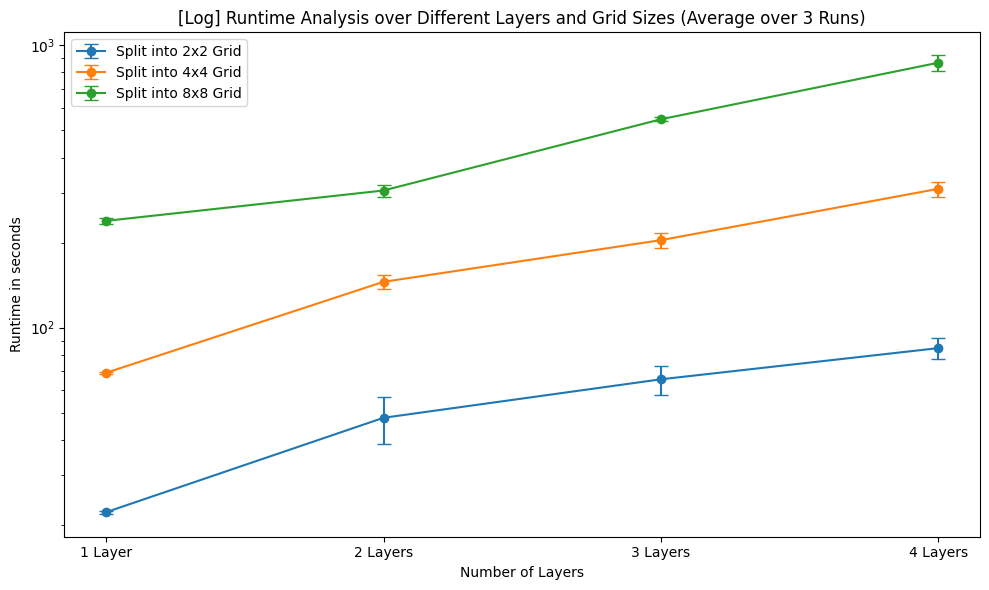

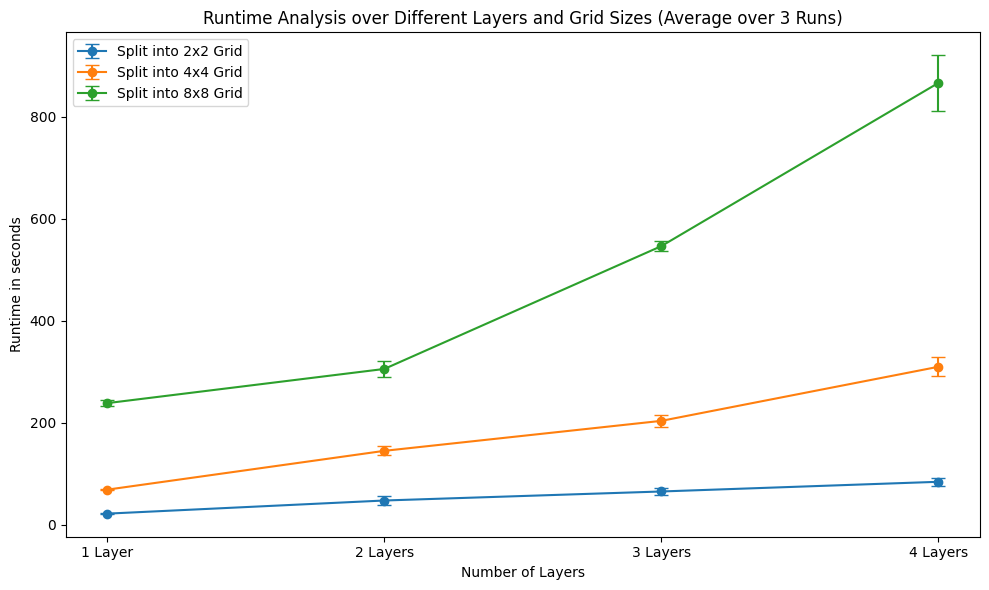

In [50]:
grid_names = list(grid_splits.keys())
layer_set_names = list(layer_subsets.keys())

fig, ax = plt.subplots(figsize=(10, 6))

for grid_name in grid_names:
    times_avg_sec = [runtime_data[grid_name][ls_name]["single_region_time_avg"] for ls_name in layer_set_names]
    times_std_sec = [runtime_data[grid_name][ls_name]["single_region_time_std"] for ls_name in layer_set_names]

    ax.errorbar(layer_set_names, times_avg_sec, yerr=times_std_sec, marker="o", capsize=5, label=f"Split into {grid_name}")

ax.set_xlabel("Number of Layers")
ax.set_ylabel("Runtime in seconds")
ax.set_title("[Log] Runtime Analysis over Different Layers and Grid Sizes (Average over 3 Runs)")
ax.legend()
ax.set_yscale("log") 
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
for grid_name in grid_names:
    times = [runtime_data[grid_name][ls_name]["single_region_time_avg"] for ls_name in layer_set_names]
    std = [runtime_data[grid_name][ls_name]["single_region_time_std"] for ls_name in layer_set_names]
    
    ax.errorbar(layer_set_names, times, yerr=std, marker="o", capsize=5, label=f"Split into {grid_name}")

ax.set_xlabel("Number of Layers")
ax.set_ylabel("Runtime in seconds")
ax.set_title("Runtime Analysis over Different Layers and Grid Sizes (Average over 3 Runs)")
ax.legend()
plt.tight_layout()
plt.show()